In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split

movies = pd.read_csv('../movies.csv', sep=',')
ratings = pd.read_csv('../ratings.csv', sep=',')
ratings_merged = pd.merge(ratings[ratings['rating'] >= 4.0], movies, on='movieId')
basket = pd.crosstab(ratings_merged['userId'], ratings_merged['title']).astype('bool')
basket

title,'71 (2014),'Hellboy': The Seeds of Creation (2004),'Salem's Lot (2004),'Til There Was You (1997),"'burbs, The (1989)",(500) Days of Summer (2009),*batteries not included (1987),...And Justice for All (1979),00 Schneider - Jagd auf Nihil Baxter (1994),1-900 (06) (1994),...,Zombieland (2009),Zookeeper (2011),Zoolander (2001),Zootopia (2016),Zulu (1964),[REC] (2007),[REC]² (2009),eXistenZ (1999),xXx (2002),¡Three Amigos! (1986)
userId,,,,,,,,,,,,,,,,,,,,,
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
5,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
606,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
607,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
608,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False


In [2]:
second_basket = basket.copy()
second_basket = second_basket.astype(int)
basket_sums = second_basket.sum(axis=0)
basket_sums = basket_sums.sort_values(ascending=False)
basket_sums

title
Shawshank Redemption, The (1994)                                                                             274
Forrest Gump (1994)                                                                                          249
Pulp Fiction (1994)                                                                                          244
Silence of the Lambs, The (1991)                                                                             225
Matrix, The (1999)                                                                                           222
                                                                                                            ... 
Sin City: A Dame to Kill For (2014)                                                                            1
*batteries not included (1987)                                                                                 1
Investigation of a Citizen Above Suspicion (Indagine su un cittadino al di sopra di ogni s

In [3]:
[movie for movie in basket_sums.index if "Clerks" in movie]

['Clerks (1994)', 'Clerks II (2006)']

In [4]:
the_movie = 'Clerks (1994)'

In [5]:
basket_sums[the_movie]

np.int64(68)

In [6]:
X = second_basket.drop([the_movie], axis=1)
y = second_basket[the_movie]

In [7]:
X.shape

(609, 6296)

In [8]:
y.shape

(609,)

In [9]:
y.value_counts(normalize=True)

Clerks (1994)
0    0.888342
1    0.111658
Name: proportion, dtype: float64

In [10]:
X

title,'71 (2014),'Hellboy': The Seeds of Creation (2004),'Salem's Lot (2004),'Til There Was You (1997),"'burbs, The (1989)",(500) Days of Summer (2009),*batteries not included (1987),...And Justice for All (1979),00 Schneider - Jagd auf Nihil Baxter (1994),1-900 (06) (1994),...,Zombieland (2009),Zookeeper (2011),Zoolander (2001),Zootopia (2016),Zulu (1964),[REC] (2007),[REC]² (2009),eXistenZ (1999),xXx (2002),¡Three Amigos! (1986)
userId,,,,,,,,,,,,,,,,,,,,,
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
606,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
607,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
608,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0


In [11]:
X.sum(axis=1)

userId
1      200
2       19
3       16
4      128
5       23
      ... 
606    612
607    111
608    280
609     10
610    614
Length: 609, dtype: int64

In [13]:
from sklearn.model_selection import train_test_split
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=1917, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=1917, stratify=y_temp)

In [14]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report, log_loss, roc_auc_score

In [15]:
depths_to_try = range(1, 6)
best_depth = None
best_val_loss = float('inf')
best_model = None

for depth in depths_to_try:
    model = GradientBoostingClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=depth,
        random_state=42
    )
    model.fit(X_train, y_train)
    y_val_proba = model.predict_proba(X_val)
    val_loss = log_loss(y_val, y_val_proba)

    print(f"Log Loss на валидации при depth={depth}: {val_loss:.4f}")
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_depth = depth
        best_model = model
print(f"Лучшая глубина дерева = {best_depth} (с ошибкой {best_val_loss:.4f})")

y_test_proba = best_model.predict_proba(X_test)
y_test_class = best_model.predict(X_test)

final_loss = log_loss(y_test, y_test_proba)
final_roc_auc = roc_auc_score(y_test, y_test_proba[:, 1])

print(f"Log Loss: {final_loss:.4f}")
print(f"ROC-AUC: {final_roc_auc:.4f}")
print("Отчет по классификации:")
print(classification_report(y_test, y_test_class))

Log Loss на валидации при depth=1: 0.2965
Log Loss на валидации при depth=2: 0.2753
Log Loss на валидации при depth=3: 0.2735
Log Loss на валидации при depth=4: 0.2967
Log Loss на валидации при depth=5: 0.3295
Лучшая глубина дерева = 3 (с ошибкой 0.2735)
Log Loss: 0.2630
ROC-AUC: 0.8457
Отчет по классификации:
              precision    recall  f1-score   support

           0       0.94      0.96      0.95        82
           1       0.62      0.50      0.56        10

    accuracy                           0.91        92
   macro avg       0.78      0.73      0.75        92
weighted avg       0.91      0.91      0.91        92



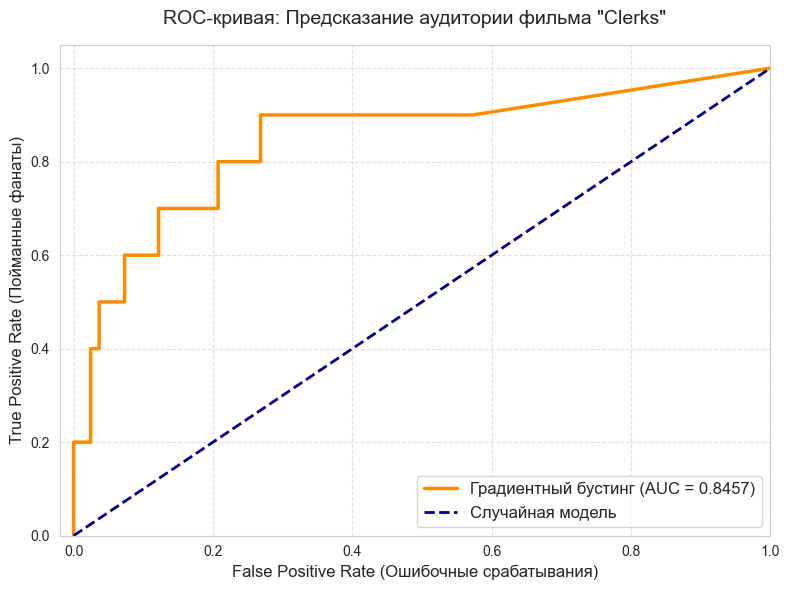

In [18]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

y_test_proba = best_model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_test_proba)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2.5,
         label=f'Градиентный бустинг (AUC = {0.8457})') # Вписал твой шикарный результат!
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Случайная модель')
plt.xlim([-0.02, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (Ошибочные срабатывания)', fontsize=12)
plt.ylabel('True Positive Rate (Пойманные фанаты)', fontsize=12)
plt.title('ROC-кривая: Предсказание аудитории фильма "Clerks"', fontsize=14, pad=15)
plt.legend(loc="lower right", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

ТОП-10 фильмов-индикаторов для 'Клерков':
                                      Movie  Importance
                            Mallrats (1995)    0.058572
                          Paper, The (1994)    0.037860
                  Autumn in New York (2000)    0.034786
                         Chasing Amy (1997)    0.031550
               Bullets Over Broadway (1994)    0.029993
                         Warm Bodies (2013)    0.029278
                    Sixth Sense, The (1999)    0.029008
                          Green Zone (2010)    0.028521
                Natural Born Killers (1994)    0.027379
South Park: Bigger, Longer and Uncut (1999)    0.023518


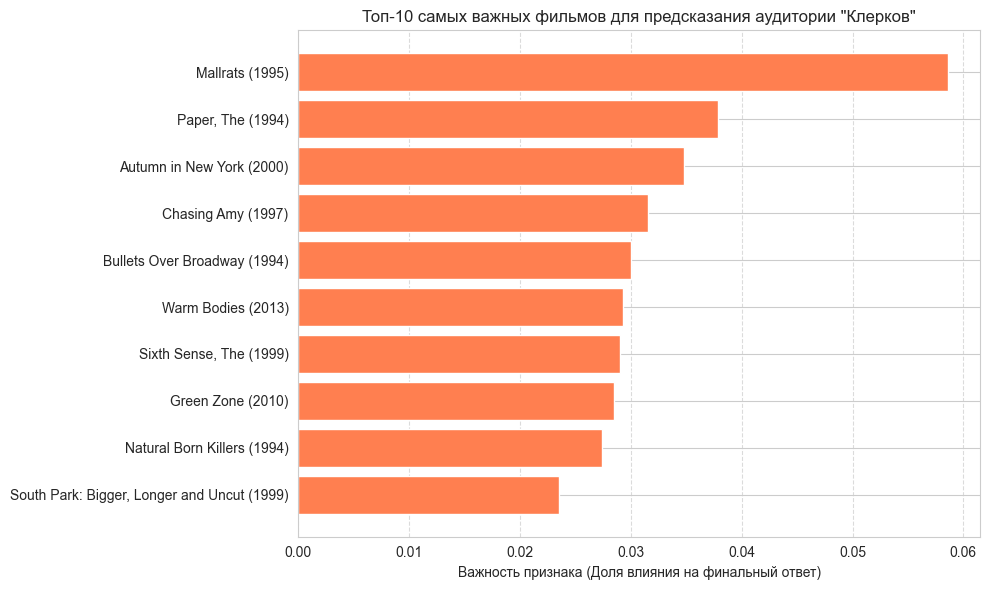

In [16]:
import pandas as pd
import matplotlib.pyplot as plt

importances = best_model.feature_importances_
feature_importance_df = pd.DataFrame({
    'Movie': X_train.columns,
    'Importance': importances
})

top_10_features = feature_importance_df.sort_values(by='Importance', ascending=False).head(10)

print("ТОП-10 фильмов-индикаторов для 'Клерков':")
print(top_10_features.to_string(index=False))

plt.figure(figsize=(10, 6))

plt.barh(top_10_features['Movie'][::-1], top_10_features['Importance'][::-1], color='coral')
plt.xlabel('Важность признака (Доля влияния на финальный ответ)')
plt.title('Топ-10 самых важных фильмов для предсказания аудитории "Клерков"')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

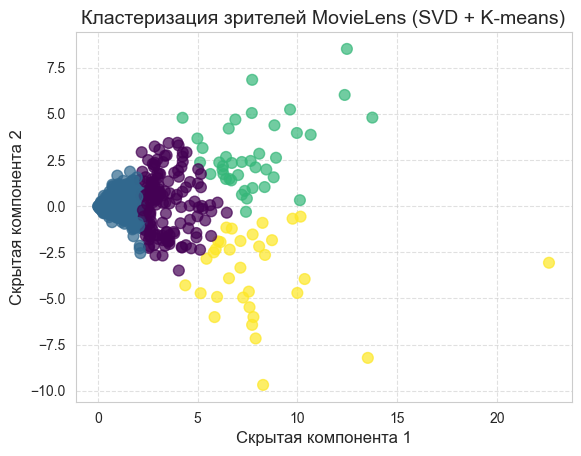

In [19]:
from sklearn.decomposition import TruncatedSVD
from sklearn.cluster import KMeans

svd = TruncatedSVD(n_components=2, random_state=42)
X_reduced = svd.fit_transform(basket)
kmeans_svd = KMeans(n_clusters=4, init='k-means++', random_state=1917, n_init=10)
y_kmeans_svd = kmeans_svd.fit_predict(X_reduced)
scatter = plt.scatter(X_reduced[:, 0], X_reduced[:, 1], c=y_kmeans_svd, cmap='viridis', s=60, alpha=0.7)
plt.title('Кластеризация зрителей MovieLens (SVD + K-means)', fontsize=14)
plt.xlabel('Скрытая компонента 1', fontsize=12)
plt.ylabel('Скрытая компонента 2', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [20]:
y_kmeans_svd.shape

(609,)

In [21]:
third_basket = second_basket[[the_movie]].copy()

In [22]:
third_basket

title,Clerks (1994)
userId,
1,0
2,0
3,0
4,0
5,0
...,...
606,1
607,0
608,0


In [23]:
third_basket.shape

(609, 1)

In [24]:
third_basket['cluster'] = y_kmeans_svd

In [25]:
third_basket

title,Clerks (1994),cluster
userId,,
1,0,3
2,0,1
3,0,1
4,0,0
5,0,1
...,...,...
606,1,3
607,0,0
608,0,2


In [26]:
import pandas as pd

# 1. Сравниваем Кластеры с Реальностью (Где прячутся настоящие фанаты?)
print("--- Таблица: Кластеры vs Реальные фанаты ---")
true_crosstab = pd.crosstab(third_basket['cluster'], third_basket['Clerks (1994)'], margins=True)
print(true_crosstab)

--- Таблица: Кластеры vs Реальные фанаты ---
Clerks (1994)    0   1  All
cluster                    
0              122  22  144
1              369  23  392
2               28  12   40
3               22  11   33
All            541  68  609


In [27]:
X_reduced.shape

(609, 2)

In [28]:
third_basket[['1st', '2nd']] = X_reduced

In [29]:
third_basket

title,Clerks (1994),cluster,1st,2nd
userId,,,,
1,0,3,5.908505,-2.341261
2,0,1,0.595637,0.789785
3,0,1,0.070714,-0.044352
4,0,0,3.247454,-2.679531
5,0,1,0.927729,-0.547038
...,...,...,...,...
606,1,3,10.363209,-3.951070
607,0,0,3.242151,-1.601947
608,0,2,7.656069,2.446647


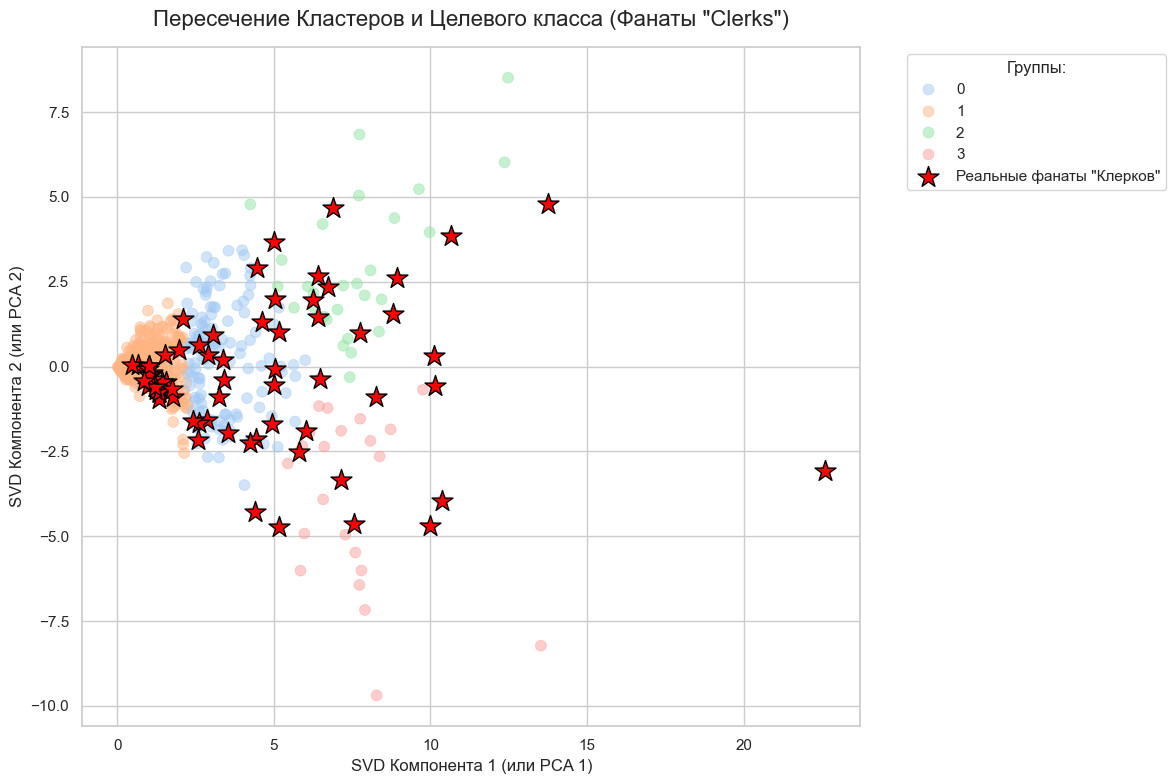

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 8))

sns.scatterplot(
    data=third_basket,
    x='1st',
    y='2nd',
    hue='cluster',
    palette='pastel',
    alpha=0.5,
    s=60,
    edgecolor=None
)

fans_df = third_basket[third_basket[the_movie] == 1]

plt.scatter(
    fans_df['1st'],
    fans_df['2nd'],
    color='red',
    marker='*',
    s=250,
    edgecolor='black',
    linewidth=1,
    zorder=5,
    label='Реальные фанаты "Клерков"'
)

plt.title('Пересечение Кластеров и Целевого класса (Фанаты "Clerks")', fontsize=16, pad=15)
plt.xlabel('SVD Компонента 1 (или PCA 1)', fontsize=12)
plt.ylabel('SVD Компонента 2 (или PCA 2)', fontsize=12)

# Немного магии с легендой, чтобы не дублировалась
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles=handles, title='Группы:', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

--- Таблица: Кластеры vs предсказанные фанаты ---
Pred_Clerks   0  1  All
Cluster                
0            20  0   20
1            59  1   60
2             2  4    6
3             3  3    6
All          84  8   92


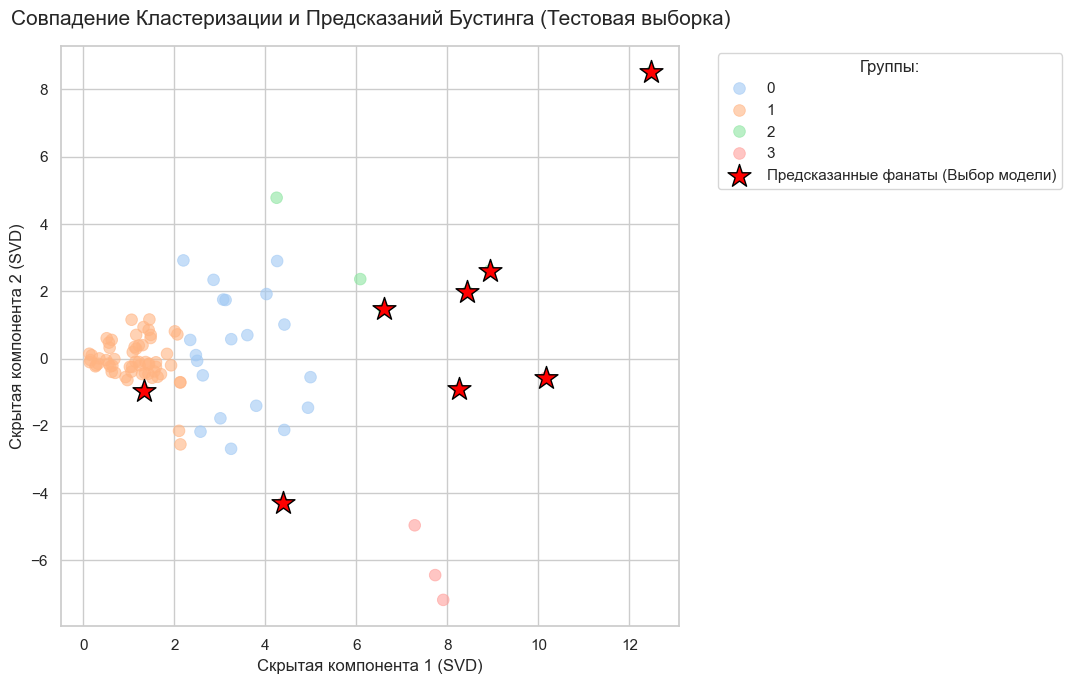

In [32]:
cluster_df = pd.DataFrame({
    'SVD_1': X_reduced[:, 0], 'SVD_2': X_reduced[:, 1], 'Cluster': y_kmeans_svd, 'True_Clerks': basket['Clerks (1994)'].values
}, index=basket.index)

y_pred_test = best_model.predict(X_test)

pred_df = pd.DataFrame({
    'Pred_Clerks': y_pred_test
}, index=X_test.index)
final_test_df = cluster_df.join(pred_df, how='inner')

print("--- Таблица: Кластеры vs предсказанные фанаты ---")
pred_crosstab = pd.crosstab(final_test_df['Cluster'], final_test_df['Pred_Clerks'], margins=True)
print(pred_crosstab)

plt.figure(figsize=(11, 7))
sns.set_theme(style="whitegrid")

sns.scatterplot(
    data=final_test_df, x='SVD_1', y='SVD_2', hue='Cluster', palette='pastel', s=70, alpha=0.6, edgecolor=None
)
predicted_fans = final_test_df[final_test_df['Pred_Clerks'] == 1]

plt.scatter(
    predicted_fans['SVD_1'], predicted_fans['SVD_2'], color='red', marker='*', s=300, edgecolor='black', zorder=5, label='Предсказанные фанаты (Выбор модели)'
)

plt.title('Совпадение Кластеризации и Предсказаний Бустинга (Тестовая выборка)', fontsize=15, pad=15)
plt.xlabel('Скрытая компонента 1 (SVD)', fontsize=12)
plt.ylabel('Скрытая компонента 2 (SVD)', fontsize=12)

handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles=handles, title='Группы:', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()